# Vascular Graph Analysis
**General pipeline for HPC and SMC regions**

---
This notebook runs the full vascular graph analysis for a selected brain region.
Set `REGION` in the configuration cell to switch between regions.

**Sections:**
1. [Configuration](#1-configuration)
2. [Imports & Setup](#2-imports--setup)
3. [Analysis Loop](#3-analysis-loop)
   - 3.1 Basic stats
   - 3.2 Lengths & diameters
   - 3.3 Degrees & HDN
   - 3.4 Boundary conditions
   - 3.5 Shortest paths
   - 3.6 Frontier comparison
   - 3.7 Min-cut
   - 3.8 Edge-disjoint paths
   - 3.9 Saturation
   - 3.10 Vessel density
   - 3.11 Distance to surface
   - 3.12 Major trees
4. [Global Comparative Analysis](#4-global-comparative-analysis)
5. [Plots](#5-plots)
   - 5.1 Connectivity & redundancy
   - 5.2 Saturation
   - 5.3 Shortest paths
   - 5.4 Vessel density
   - 5.5 Diameter & length
   - 5.6 Boundary conditions


---
## 1. Configuration
**Edit only this cell to switch between regions or change parameters.**

In [16]:
# =====================================================================
# REGION SELECTION
# =====================================================================
# Set REGION to "HPC" or "SMC"
REGION = "HPC"

# =====================================================================
# REGION CONFIGS
# =====================================================================
REGION_CONFIGS = {
    "HPC": {
        "paths": {
            "HPC_1": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl",
            "HPC_2": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut2.pkl",
            "HPC_3": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut3.pkl",
        },
        "centers": {
            "HPC_1": [1000, 3500, 1400],
            "HPC_2": [1300, 3900, 1000],
            "HPC_3": [2100, 4200, 750],
        },
        "out_root": "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED",
    },
    "SMC": {
        "paths": {
            "SMC_1": "/path/to/SMC_graph_1.pkl",
            "SMC_2": "/path/to/SMC_graph_2.pkl",
            "SMC_3": "/path/to/SMC_graph_3.pkl",
        },
        "centers": {
            "SMC_1": [1000, 2000, 1000],
            "SMC_2": [1500, 2500, 1000],
            "SMC_3": [2000, 3000, 800],
        },
        "out_root": "/home/admin/Ana/MicroBrain/output/SMC_FULL_ANALYSIS_FORMATTED",
    },
}

# =====================================================================
# ANALYSIS PARAMETERS
# =====================================================================
box_size_um  = (400, 400, 400)   # analysis box size in µm
degree_thr   = 4                 # high-degree node threshold
eps_vox      = 2.0               # tolerance for BC face detection (voxels)
bins_hist    = 40                # histogram bins

# =====================================================================
# COLORS
# =====================================================================
VESSEL_COLORS = {
    "arteriole": "#d62728",
    "venule": "#1f77b4",
    "capillary": "#7f7f7f",
    "unknown": "#c7c7c7",
}

# Auto-assign box colors (up to 6 boxes)
_PALETTE = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

# =====================================================================
# DERIVED — do not edit below this line
# =====================================================================
cfg      = REGION_CONFIGS[REGION]
PATHS    = cfg["paths"]
CENTERS  = cfg["centers"]
out_root = cfg["out_root"]

BOX_ORDER = list(PATHS.keys())
BOX_LABEL = " vs ".join(BOX_ORDER)
BOX_COL   = {name: _PALETTE[i] for i, name in enumerate(BOX_ORDER)}

print(f"Region  : {REGION}")
print(f"Boxes   : {BOX_ORDER}")
print(f"Output  : {out_root}")

# Image resolution scale 
res_um_per_vox = (1.625, 1.625, 2.5)

Region  : HPC
Boxes   : ['HPC_1', 'HPC_2', 'HPC_3']
Output  : /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED


---
## 2. Imports & Setup

In [17]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ttest_ind, ttest_rel

# --- toolbox ---
sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# --- constants ---
ARTERY   = 2
VEIN     = 3
CAPILLARY = 4

# --- output folder ---
os.makedirs(out_root, exist_ok=True)

# --- resolution safety check ---
try:
    res_um_per_vox
except NameError:
    res_um_per_vox = 1.0
    print("[WARNING] res_um_per_vox not defined — using 1.0")

print("Setup complete.")

Setup complete.


---
## 3. Analysis Loop
Runs all analyses for each box. Results are collected in global lists and saved per-box as CSV/VTP.


  HPC — HPC_1

Units: coords/length=um | diameter=vox
Box  x:[1425.0, 1825.0]  y:[5487.5, 5887.5]  z:[3300.0, 3700.0]
has_arteries=True | has_veins=True

--- 3.1 Basic stats ---
Duplicated edges: {'n_pairs_duplicated': 2, 'n_extra_edges': 2, 'perc_extra_edges': 0.15278838808250572}
Loops: {'n_loops': 1, 'perc_loops': 0.07639419404125286, 'loop_indices': [424]}

--- 3.2 Lengths & diameters ---

- Average length by nkind:

nkind=2 (arteriole): mean length = 28.068814
nkind=3 (venule): mean length = 38.127434
nkind=4 (capillary): mean length = 47.734570

- Average diameter by nkind:

arteriole (nkind=2, n=96):
  mean:   6.16
  median: 6.01
  p5–p95: 3.41 – 9.32

venule (nkind=3, n=22):
  mean:   9.22
  median: 9.73
  p5–p95: 6.03 – 11.70

capillary (nkind=4, n=1191):
  mean:   5.31
  median: 5.09
  p5–p95: 4.27 – 7.03



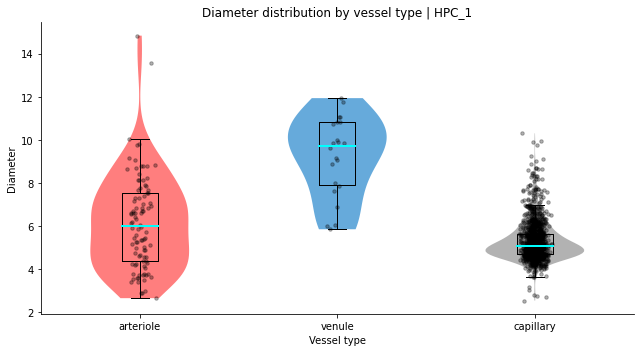

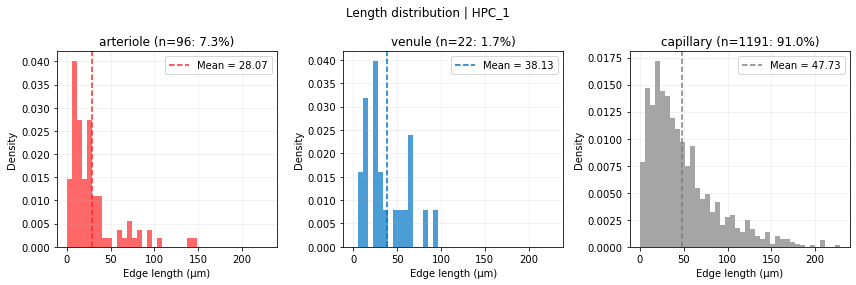

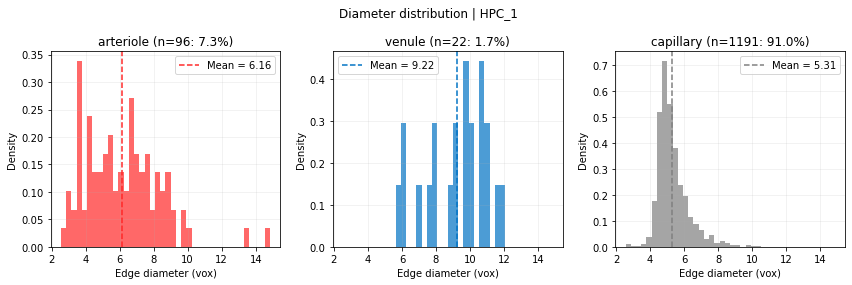

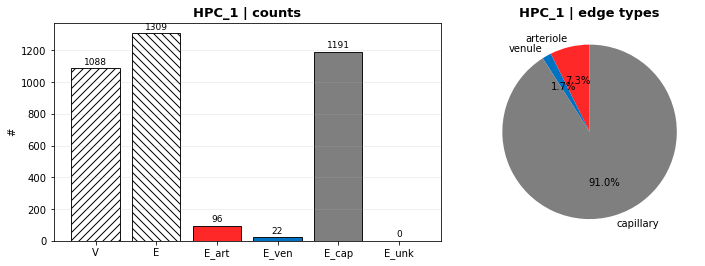


--- 3.3 Degrees & HDN ---
Unique degrees: [1 3 4 5 6]
HDN (>= 4): 66


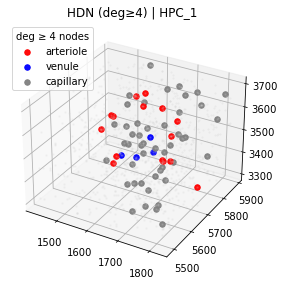


--- 3.4 Boundary conditions ---


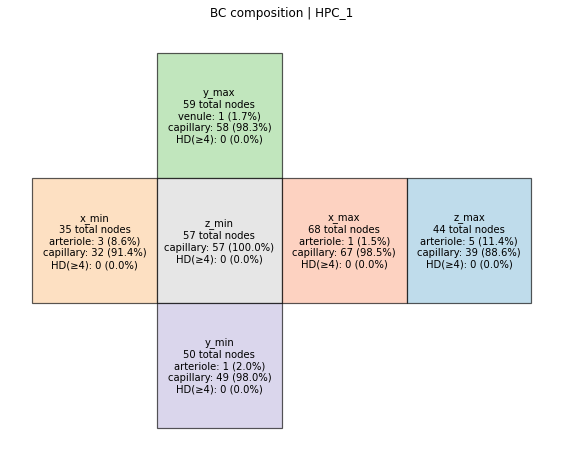

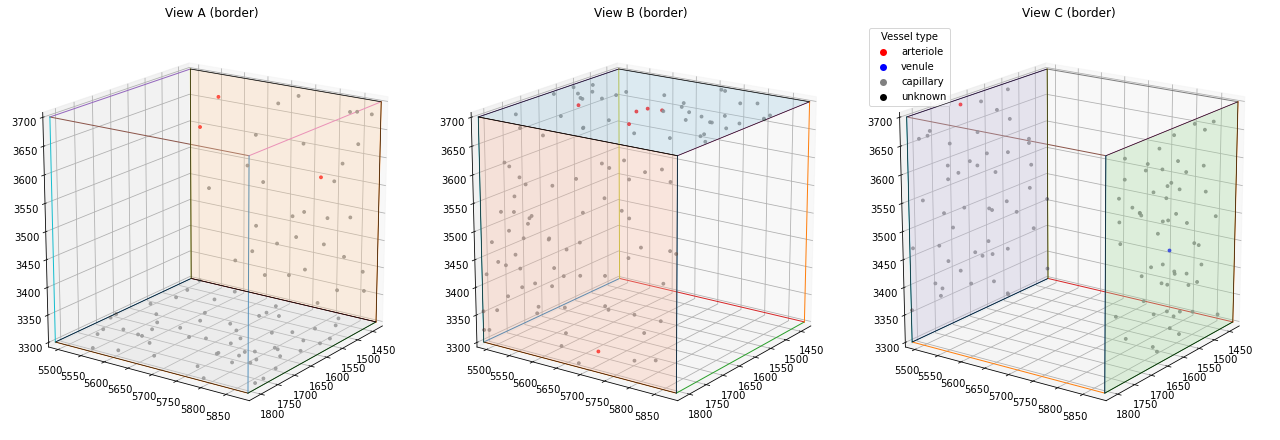


--- 3.5 Shortest paths ---
A-C frontier: 44  |  venous nodes: 23  |  paths found: 41


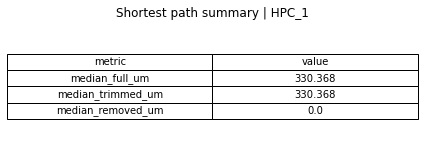


--- 3.6 Frontier comparison ---

--- 3.7 Min-cut ---
Min-cut = 21.0  |  cut edges = 21
[export_edge_ids_vtp] Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_1_mincut_edges.vtp

--- 3.8 Edge-disjoint paths ---
Edge-disjoint A-V paths = 21

--- 3.9 Saturation ---
A-C cap edges: 70  |  V-C cap edges: 24
Saturation A-side: 30.0%
Saturation V-side: 87.5%

--- 3.10 Vessel density ---
Global VVD: 0.0212  |  Global VLD: 931.0
Total vessel length: 60.39 mm

--- 3.12 Major trees ---
Arteriole components:
  component_id  n_nodes  n_edges  n_branch_nodes  edge_threshold  is_major  major_tree_id  pct_nodes  pct_edges
            4       32       31               9              10      True              1  29.357798  32.291667
            3       12       11               3              10      True              2  11.009174  11.458333
           14       12       11               4              10      True              3  11.009174  11.458333
           12        7       

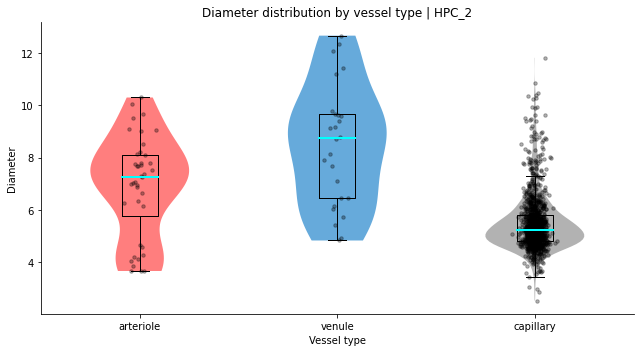

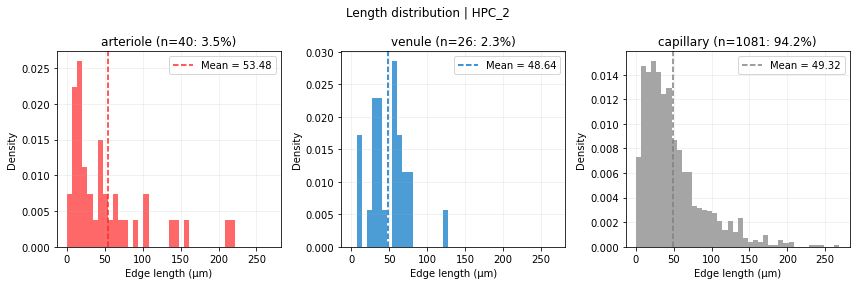

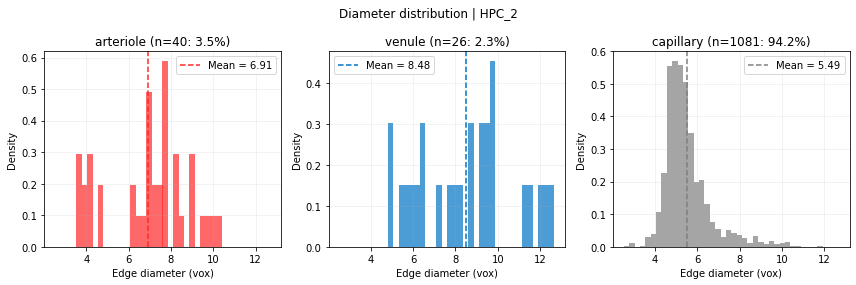

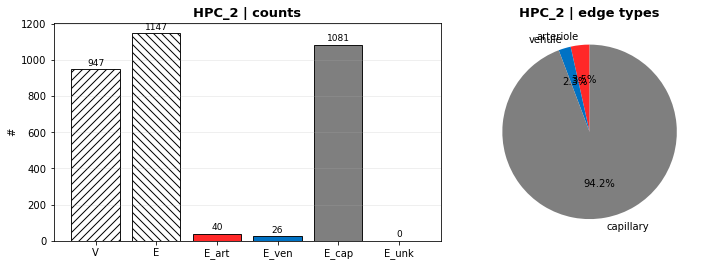


--- 3.3 Degrees & HDN ---
Unique degrees: [1 3 4 5 8]
HDN (>= 4): 54


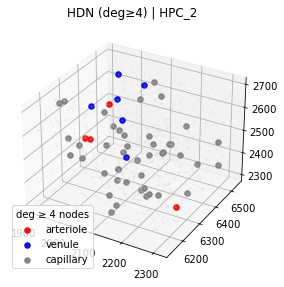


--- 3.4 Boundary conditions ---


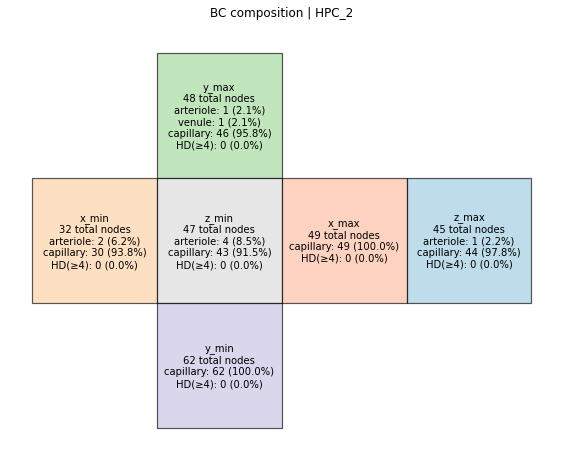

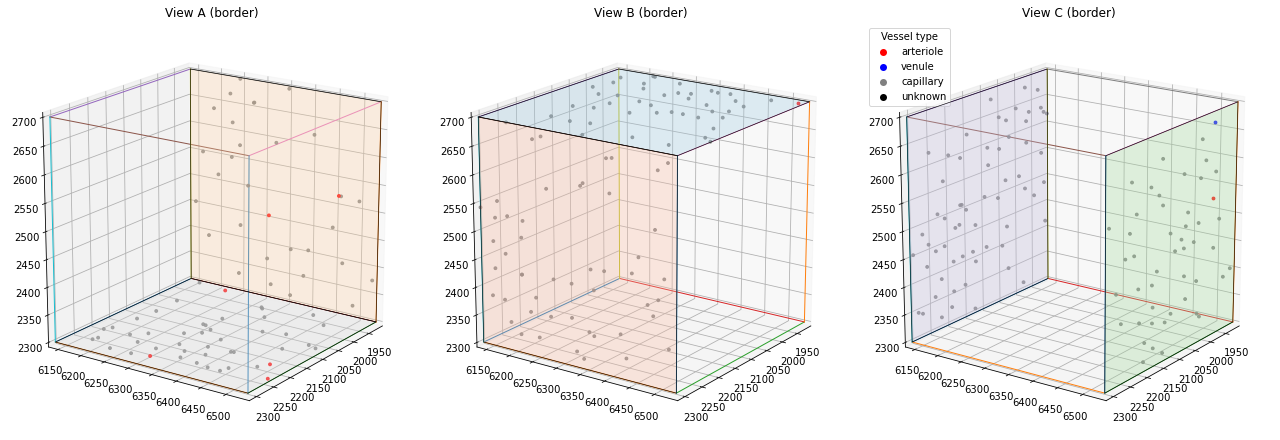


--- 3.5 Shortest paths ---
A-C frontier: 22  |  venous nodes: 27  |  paths found: 19


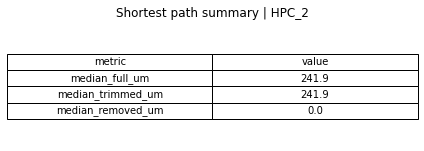


--- 3.6 Frontier comparison ---

--- 3.7 Min-cut ---
Min-cut = 26.0  |  cut edges = 26
[export_edge_ids_vtp] Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_2_mincut_edges.vtp

--- 3.8 Edge-disjoint paths ---
Edge-disjoint A-V paths = 26

--- 3.9 Saturation ---
A-C cap edges: 37  |  V-C cap edges: 38
Saturation A-side: 70.3%
Saturation V-side: 68.4%

--- 3.10 Vessel density ---
Global VVD: 0.0213  |  Global VLD: 880.6
Total vessel length: 56.71 mm

--- 3.12 Major trees ---
Arteriole components:
  component_id  n_nodes  n_edges  n_branch_nodes  edge_threshold  is_major  major_tree_id  pct_nodes  pct_edges
            2       18       17               6              10      True              1  39.130435       42.5
            6        7        8               3              10     False              0  15.217391       20.0
            5        7        6               1              10     False              0  15.217391       15.0
            4        5       

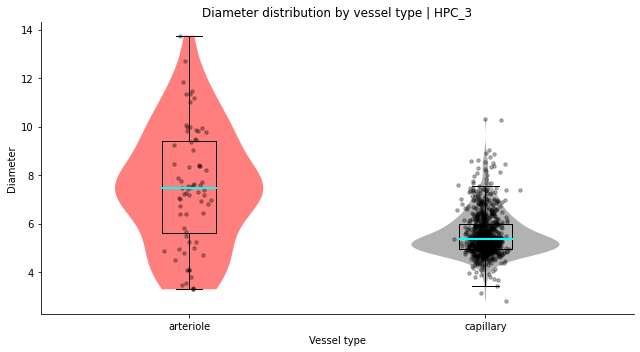

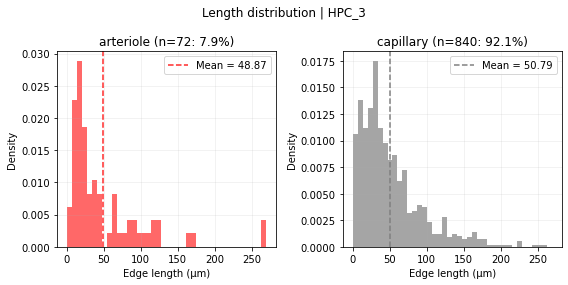

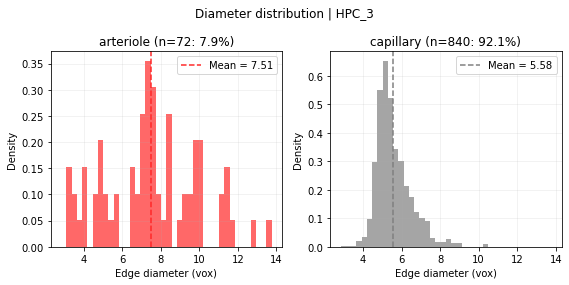

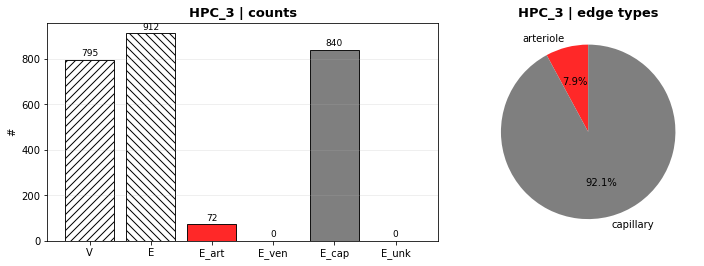


--- 3.3 Degrees & HDN ---
Unique degrees: [1 3 4 5 6]
HDN (>= 4): 37


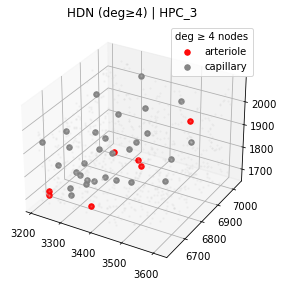


--- 3.4 Boundary conditions ---


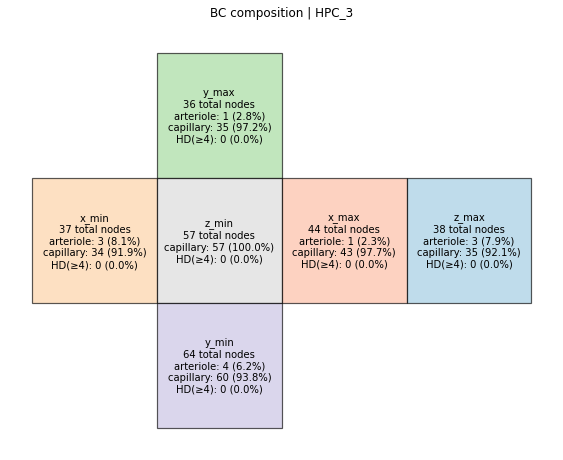

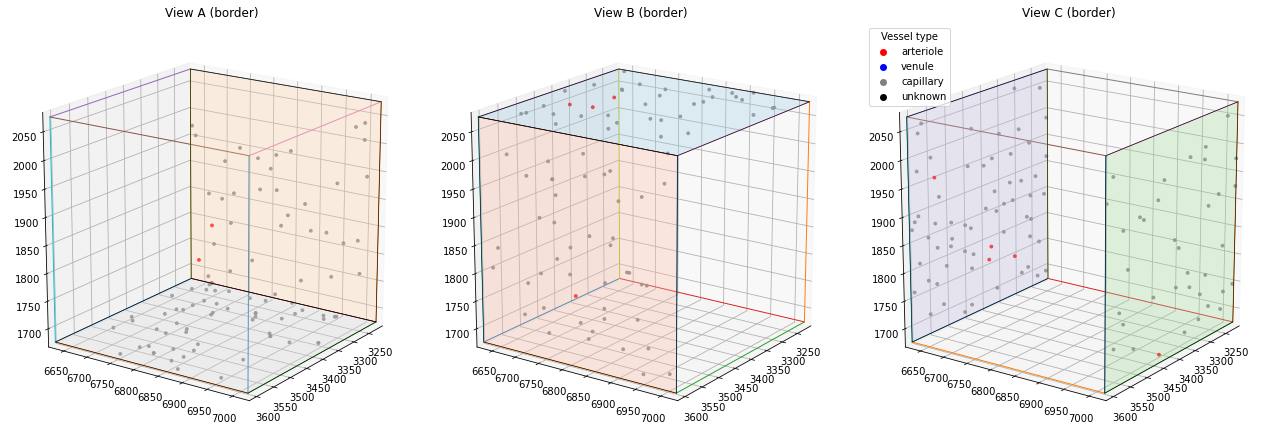


--- 3.5 Shortest paths ---
[HPC_3] Skipped — missing arteries or veins.

--- 3.6 Frontier comparison ---
[HPC_3] Skipped — missing arteries or veins.

--- 3.7 Min-cut ---
[HPC_3] Skipped — missing arteries or veins.

--- 3.8 Edge-disjoint paths ---
[HPC_3] Skipped — missing arteries or veins.

--- 3.9 Saturation ---
[HPC_3] No veins. A-side metrics computed.
A-C cap edges: 52  |  V-C cap edges: nan
Saturation A-side: N/A
Saturation V-side: N/A

--- 3.10 Vessel density ---
Global VVD: 0.0187  |  Global VLD: 715.3
Total vessel length: 46.18 mm

--- 3.12 Major trees ---
Arteriole components:
  component_id  n_nodes  n_edges  n_branch_nodes  edge_threshold  is_major  major_tree_id  pct_nodes  pct_edges
            2       47       46              18              10      True              1      58.75  63.888889
            6       10        9               3              10     False              0      12.50  12.500000
            1        6        5               1              10     F

In [18]:
# =====================================================================
# COLLECTORS  (reset every time this cell runs)
# =====================================================================
all_summaries          = []
diam_length_rows       = []
av_path_size_rows      = []
av_rows                = []
bc_rows                = []
bc_long_rows           = []
hdn_nodes_rows         = []
mincut_rows            = []
redundancy_rows        = []
comparison_detail_rows = []
comparison_summ_rows   = []
density_boxes_rows     = []
trimmed_rows           = []
saturation_rows        = []

# =====================================================================
# MAIN LOOP
# =====================================================================
for name, path in PATHS.items():
    center = CENTERS[name]

    print(f"\n{'='*54}")
    print(f"  {REGION} — {name}")
    print(f"{'='*54}\n")

    # ------------------------------------------------------------------
    # Load graph
    # ------------------------------------------------------------------
    g = load_graph(path)
    G = keep_giant_component(g)

    g_unit = G["unit"]          if "unit"          in G.attributes() else "unknown"
    d_unit = G["diameter_unit"] if "diameter_unit" in G.attributes() else "unknown"
    print(f"Units: coords/length={g_unit} | diameter={d_unit}")

    # analysis box
    cut_box = make_box_in_um(center, box_size_um, res_um_per_vox=res_um_per_vox)
    validate_box_faces(cut_box)
    print(f"Box  x:[{cut_box['xmin']:.1f}, {cut_box['xmax']:.1f}]  "
          f"y:[{cut_box['ymin']:.1f}, {cut_box['ymax']:.1f}]  "
          f"z:[{cut_box['zmin']:.1f}, {cut_box['zmax']:.1f}]")

    # penalization weights for weighted-path comparison
    add_penalization_weights(G, new_weight_attr="w_cap_prior",
                             edge_type_attr="nkind", length_attr="length",
                             penalty_art=1e5, penalty_ven=1e5)

    # vessel-type availability flags
    nk_all       = np.asarray(G.es["nkind"], int)
    has_arteries = int(ARTERY) in nk_all
    has_veins    = int(VEIN)   in nk_all
    print(f"has_arteries={has_arteries} | has_veins={has_veins}")

    # ==================================================================
    # 3.1  Basic stats
    # ==================================================================
    print("\n--- 3.1 Basic stats ---")
    dup   = duplicated_edge_stats(G)
    loops = loop_edge_stats(G)
    print("Duplicated edges:", dup)
    print("Loops:", loops)

    # ==================================================================
    # 3.2  Lengths & diameters
    # ==================================================================
    print("\n--- 3.2 Lengths & diameters ---")
    avg_len_dict = get_avg_length_nkind(G)
    avg_len_by_type = {EDGE_NKIND_TO_LABEL.get(int(k), str(k)): float(v)
                       for k, v in avg_len_dict.items()}

    diam_stats = diameter_stats_nkind(G, label_dict=EDGE_NKIND_TO_LABEL,
                                      plot=True, title_suffix=name)

    e_diam = np.asarray(G.es["diameter"], float)
    e_leng = np.asarray(G.es["length"],   float)
    nk     = np.asarray(G.es["nkind"],    int)

    etype_counts = edge_type_counts(nk, EDGE_NKIND_TO_LABEL)
    E_arteriole  = int(etype_counts["arteriole"])
    E_venule     = int(etype_counts["venule"])
    E_capillary  = int(etype_counts["capillary"])
    E_unknown    = int(etype_counts["unknown"])

    for k in np.unique(nk):
        lab = EDGE_NKIND_TO_LABEL.get(int(k), str(k))
        m   = nk == k
        if np.any(m):
            diam_length_rows.append(pd.DataFrame({
                "graph": name, "type": str(lab),
                "diameter_vox": e_diam[m], "length_um": e_leng[m],
            }))

    plot_hist_by_category_general(
        values=e_leng, category=nk, label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist, layout="horizontal", density=True, show_mean=True,
        variable_name="Edge length (µm)", category_name="Vessel type",
        main_title=f"Length distribution | {name}")

    plot_hist_by_category_general(
        values=e_diam, category=nk, label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist, layout="horizontal", density=True, show_mean=True,
        variable_name="Edge diameter (vox)", category_name="Vessel type",
        main_title=f"Diameter distribution | {name}")

    # pie + bar de composición por box (se muestra en el loop)
    plot_pies_with_bars_edge_types(
        pd.DataFrame([{
            "graph":        name,
            "V":            int(G.vcount()),
            "E":            int(G.ecount()),
            "E_arteriole":  E_arteriole,
            "E_venule":     E_venule,
            "E_capillary":  E_capillary,
            "E_unknown":    E_unknown,
        }]),
        box_order=[name],
        type_colors=VESSEL_COLORS,
    )
    
    # ==================================================================
    # 3.3  Degrees & HDN
    # ==================================================================
    print("\n--- 3.3 Degrees & HDN ---")
    get_degrees(G, threshold=degree_thr)

    hdn    = analyze_hdn_pattern_in_box(G, box=cut_box, coords_attr="coords",
                                        space="um", degree_thr=degree_thr, eps_vox=eps_vox)
    deg    = np.asarray(G.degree(), int)
    coords = np.asarray(G.vs["coords"], float)

    for v in np.where(deg >= degree_thr)[0]:
        t = infer_node_type_from_incident_edges(G, int(v))
        x, y, z = coords[int(v)]
        hdn_nodes_rows.append({"graph": name, "v": int(v),
                                "x": float(x), "y": float(y), "z": float(z),
                                "degree": int(deg[int(v)]), "type": t})

    plot_degree_nodes_spatial(G, coords_attr="coords", degree_min=degree_thr,
                              by_type=True, title=f"HDN (deg≥{degree_thr}) | {name}")

    # ==================================================================
    # 3.4  Boundary conditions
    # ==================================================================
    print("\n--- 3.4 Boundary conditions ---")
    bc = analyze_bc_faces(G, cut_box, coords_attr="coords", space="um",
                          eps_vox=eps_vox, degree_thr=degree_thr, mode="border",
                          diam_attr="diameter", return_diameter_values=True)

    bc_long_df = bc_diameter_longtable(bc, box_name=name).copy()
    bc_long_df["graph"] = name
    bc_long_rows.append(bc_long_df)

    bc_df = bc_faces_table(bc, box_name=name).copy()
    bc_df["graph"] = name
    bc_rows.append(bc_df)

    plot_bc_cube_net(bc, title=f"BC composition | {name}")
    plot_bc_3_cubes_tinted(G, cut_box, coords_attr="coords",
                           space="um", eps_vox=eps_vox, mode="border")

    bc_df.to_csv(os.path.join(out_root, f"{name}_bc_faces.csv"), index=False)

    # ==================================================================
    # 3.5  Shortest paths  (requires arteries AND veins)
    # ==================================================================
    print("\n--- 3.5 Shortest paths ---")
    source_frontiers = []
    target_venous    = []
    shortest_paths_noA = []
    dist_no            = []
    A, V               = [], []

    if has_arteries and has_veins:
        shortest_paths_noA, dist_no, _, source_frontiers, target_venous, A, V = \
            shortest_av_paths_from_ac_frontier(
                G, artery_continuity=False, edge_type_attr="nkind",
                weight_attr="length", tie_break_edges=True, tol=1e-6)

        print(f"A-C frontier: {len(A)}  |  venous nodes: {len(V)}  |  paths found: {len(shortest_paths_noA)}")

        for p, d, a, v in zip(shortest_paths_noA, dist_no, source_frontiers, target_venous):
            av_path_size_rows.append({"graph": name, "source_frontier": int(a),
                                      "target_venous": int(v),
                                      "path_len_edges": int(len(p) - 1),
                                      "path_len_um": float(d)})

        rows_trimmed = []
        for p in shortest_paths_noA:
            full_eids  = path_to_edge_ids(G, p)
            full_len   = float(np.sum(np.asarray(G.es[full_eids]["length"], float))) if full_eids else np.nan
            trim_len   = float(trimmed_capillary_length(G, p))
            removed_um = full_len - trim_len if np.isfinite(full_len) and np.isfinite(trim_len) else np.nan
            removed_fr = removed_um / full_len if np.isfinite(removed_um) and full_len > 0 else np.nan
            rows_trimmed.append({"graph": name, "full_len_um": full_len,
                                  "trimmed_capillary_len_um": trim_len,
                                  "removed_um": removed_um, "removed_frac": removed_fr,
                                  "n_edges_full": int(len(p) - 1)})

        df_trimmed = pd.DataFrame(rows_trimmed)
        trimmed_rows.extend(rows_trimmed)

        av_rows.append({
            "graph": name,
            "A_AC_nodes": int(len(A)), "V_nodes": int(len(V)),
            "pairs_with_path": int(len(shortest_paths_noA)),
            "all_frontiers_reached_vein": bool(len(shortest_paths_noA) == len(A)),
            "median_full_len_um":             float(np.nanmedian(df_trimmed["full_len_um"])),
            "median_trimmed_capillary_len_um": float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])),
            "median_removed_um":              float(np.nanmedian(df_trimmed["removed_um"])),
            "median_removed_frac":            float(np.nanmedian(df_trimmed["removed_frac"])),
        })

        if shortest_paths_noA:
            export_paths_vtp(G, shortest_paths_noA,
                             os.path.join(out_root, f"{name}_shortest_paths_AC_to_vein.vtp"))
            df_trimmed.to_csv(os.path.join(out_root, f"{name}_trimmed_shortest_paths.csv"), index=False)

        dataframe_to_table_figure(
            pd.DataFrame({"metric": ["median_full_um", "median_trimmed_um", "median_removed_um"],
                          "value":  [float(np.nanmedian(df_trimmed["full_len_um"])),
                                     float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])),
                                     float(np.nanmedian(df_trimmed["removed_um"]))]}),
            title=f"Shortest path summary | {name}", figsize=(6, 2.2))

    else:
        df_trimmed = pd.DataFrame()
        av_rows.append({"graph": name, "A_AC_nodes": 0, "V_nodes": 0, "pairs_with_path": 0})
        print(f"[{name}] Skipped — missing arteries or veins.")

    # ==================================================================
    # 3.6  Frontier comparison  (restricted vs weighted)
    # ==================================================================
    print("\n--- 3.6 Frontier comparison ---")
    if has_arteries and has_veins:
        df_cmp_local, _, _ = compare_frontier_restricted_vs_weighted(
            G, edge_type_attr="nkind", length_weight_attr="length",
            weighted_attr="w_cap_prior", tie_break_edges=True, tol=1e-6)
        df_cmp_local["graph"] = name
        comparison_detail_rows.append(df_cmp_local)
        cmp_summary = summarize_frontier_comparison_restricted_vs_weighted(df_cmp_local, name)
    else:
        df_cmp_local = pd.DataFrame()
        # llamada segura: la función tiene guard para df vacío sin columnas
        cmp_summary = {
            "graph": name, "n_pairs": 0, "n_target_changed": 0,
            "pct_target_changed": np.nan, "n_delta_um_nonzero": 0,
            "pct_delta_um_nonzero": np.nan, "n_delta_um_positive": 0,
            "pct_delta_um_positive": np.nan, "n_delta_um_negative": 0,
            "pct_delta_um_negative": np.nan, "n_delta_edges_nonzero": 0,
            "pct_delta_edges_nonzero": np.nan, "n_delta_edges_positive": 0,
            "pct_delta_edges_positive": np.nan, "n_delta_edges_negative": 0,
            "pct_delta_edges_negative": np.nan, "median_delta_um": np.nan,
            "mean_delta_um": np.nan, "median_delta_edges": np.nan,
            "mean_delta_edges": np.nan, "n_weighted_paths_using_artery": 0,
            "pct_weighted_paths_using_artery": np.nan,
            "median_weighted_arterial_len_um": np.nan,
            "mean_weighted_arterial_len_um": np.nan,
        }
        print(f"[{name}] Skipped — missing arteries or veins.")

    comparison_summ_rows.append(cmp_summary)
    df_cmp_local.to_csv(os.path.join(out_root, f"{name}_frontier_comparison.csv"), index=False)
    pd.DataFrame([cmp_summary]).to_csv(
        os.path.join(out_root, f"{name}_frontier_comparison_summary.csv"), index=False)

    # ==================================================================
    # 3.7  Min-cut  (principal connectivity metric)
    # ==================================================================
    print("\n--- 3.7 Min-cut ---")
    if has_arteries and has_veins:
        mc       = av_min_cut_metrics(G, edge_type_attr="nkind", per_edge_capacity=1.0)
        mc_counts = cut_type_counts(mc["cut_edge_types"])
        print(f"Min-cut = {mc['min_cut_value']}  |  cut edges = {mc['n_cut_edges_original_graph']}")
        if mc["cut_edge_ids"]:
            export_edge_ids_vtp(G, mc["cut_edge_ids"],
                                os.path.join(out_root, f"{name}_mincut_edges.vtp"))
    else:
        mc = {"min_cut_value": np.nan, "max_flow_value": np.nan,
              "n_cut_edges_original_graph": 0, "n_arterial_nodes": 0, "n_venous_nodes": 0,
              "cut_edge_ids": [], "cut_edge_types": []}
        mc_counts = {"min_cut_n_arteriole_edges": 0, "min_cut_n_venule_edges": 0,
                     "min_cut_n_capillary_edges": 0, "min_cut_n_unknown_edges": 0}
        print(f"[{name}] Skipped — missing arteries or veins.")

    mincut_row = {"graph": name,
                  "min_cut_value":          float(mc["min_cut_value"]) if np.isfinite(mc["min_cut_value"]) else np.nan,
                  "max_flow_value":         float(mc["max_flow_value"]) if np.isfinite(mc["max_flow_value"]) else np.nan,
                  "n_cut_edges":            int(mc["n_cut_edges_original_graph"]),
                  "n_arterial_nodes":       int(mc["n_arterial_nodes"]),
                  "n_venous_nodes":         int(mc["n_venous_nodes"]),
                  **mc_counts}
    mincut_rows.append(mincut_row)
    pd.DataFrame([mincut_row]).to_csv(
        os.path.join(out_root, f"{name}_mincut_summary.csv"), index=False)

    # ==================================================================
    # 3.8  Edge-disjoint paths  (secondary connectivity metric)
    # ==================================================================
    print("\n--- 3.8 Edge-disjoint paths ---")
    if has_arteries and has_veins:
        redundancy       = max_edge_disjoint_av(G)
        n_disjoint       = int(redundancy["n_edge_disjoint_av"])
        independent_paths = redundancy["paths"]
        print(f"Edge-disjoint A-V paths = {n_disjoint}")
        if independent_paths:
            export_paths_vtp(G, independent_paths,
                             os.path.join(out_root, f"{name}_edge_disjoint_AV_paths.vtp"))
    else:
        n_disjoint        = 0
        independent_paths = []
        print(f"[{name}] Skipped — missing arteries or veins.")

    redundancy_rows.append({
        "graph": name,
        "min_cut_value":                float(mc["min_cut_value"]) if np.isfinite(mc["min_cut_value"]) else np.nan,
        "edge_disjoint_AV":             n_disjoint,
        "A_nodes":                      int(len(A)),
        "V_nodes":                      int(len(V)),
        "shortest_paths_n":             int(len(shortest_paths_noA)),
        "shortest_path_len_median_edges": float(np.median([len(p)-1 for p in shortest_paths_noA])) if shortest_paths_noA else np.nan,
        "shortest_path_len_p90_edges":  float(np.percentile([len(p)-1 for p in shortest_paths_noA], 90)) if shortest_paths_noA else np.nan,
        "shortest_path_len_median_um":  float(np.nanmedian(dist_no)) if len(dist_no) > 0 else np.nan,
        "trimmed_capillary_len_median_um": float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
    })

    # ==================================================================
    # 3.9  Saturation  (edge-based)
    # ==================================================================
    print("\n--- 3.9 Saturation ---")
    if has_arteries and has_veins:
        sat = saturation_interface_proxies(
            G, edge_type_attr="nkind",
            source_frontiers=source_frontiers,
            target_venous=target_venous,
            n_disjoint=n_disjoint)

    elif has_arteries:
        sat = saturation_interface_proxies(
            G, edge_type_attr="nkind",
            source_frontiers=[],
            target_venous=[],
            n_disjoint=0)

        sat.update({
            "n_vc_cap_edges_total": np.nan,
            "capillary_edges_attached_to_vein": np.nan,
            "unique_capillary_nodes_touching_vein": np.nan,
            "venous_nodes": 0,
            "vc_nodes_total": 0,
            "vc_nodes_reached": 0,
            "vc_nodes_unreached": 0,
            "n_independent_paths": 0,
            "quick_upper_bound_interface": 0,
            "saturation_ac_edges": np.nan,
            "saturation_vc_edges": np.nan,
        })

        print(f"[{name}] No veins. A-side metrics computed.")

    elif has_veins:
        sat = saturation_interface_proxies(
            G, edge_type_attr="nkind",
            source_frontiers=[],
            target_venous=[],
            n_disjoint=0)

        sat.update({
            "n_ac_cap_edges_total": np.nan,
            "capillary_edges_attached_to_artery": np.nan,
            "unique_capillary_nodes_touching_artery": np.nan,
            "arterial_nodes": 0,
            "ac_frontier_nodes_total": 0,
            "ac_frontier_nodes_used": 0,
            "ac_frontier_nodes_unused": 0,
            "n_independent_paths": 0,
            "quick_upper_bound_interface": 0,
            "saturation_ac_edges": np.nan,
            "saturation_vc_edges": np.nan,
        })

        print(f"[{name}] No arteries. V-side metrics computed.")

    else:
        sat = {
            "arterial_nodes": 0,
            "venous_nodes": 0,
            "capillary_edges_attached_to_artery": np.nan,
            "capillary_edges_attached_to_vein": np.nan,
            "unique_capillary_nodes_touching_artery": np.nan,
            "unique_capillary_nodes_touching_vein": np.nan,
            "n_ac_cap_edges_total": np.nan,
            "n_vc_cap_edges_total": np.nan,
            "ac_frontier_nodes_total": 0,
            "ac_frontier_nodes_used": 0,
            "ac_frontier_nodes_unused": 0,
            "vc_nodes_total": 0,
            "vc_nodes_reached": 0,
            "vc_nodes_unreached": 0,
            "n_independent_paths": 0,
            "quick_upper_bound_interface": np.nan,
            "saturation_ac_edges": np.nan,
            "saturation_vc_edges": np.nan,
        }
        

    sat["graph"] = name
    saturation_rows.append(sat)

    print(f"A-C cap edges: {sat['n_ac_cap_edges_total']}  |  V-C cap edges: {sat['n_vc_cap_edges_total']}")
    print(f"Saturation A-side: {sat['saturation_ac_edges']:.1%}" if np.isfinite(sat["saturation_ac_edges"]) else "Saturation A-side: N/A")
    print(f"Saturation V-side: {sat['saturation_vc_edges']:.1%}" if np.isfinite(sat["saturation_vc_edges"]) else "Saturation V-side: N/A")

    pd.DataFrame([sat]).to_csv(
        os.path.join(out_root, f"{name}_saturation.csv"), index=False)

    # ==================================================================
    # 3.10  Vessel density
    # ==================================================================
    print("\n--- 3.10 Vessel density ---")
    ms      = microsegments_from_formatted_graph(G)
    boxes   = generate_boxes(cut_box)
    ms_art  = subset_ms_by_nkind(ms, ARTERY)
    ms_ven  = subset_ms_by_nkind(ms, VEIN)
    ms_cap  = subset_ms_by_nkind(ms, CAPILLARY)

    dens_rows = []
    for b in boxes:
        for t, ms_t in [("total", ms), ("arteriole", ms_art), ("venule", ms_ven), ("capillary", ms_cap)]:
            dens_rows.append({"graph": name, "type": t,
                              "vessel_volume_density": vessel_volume_density(ms_t, b),
                              "vessel_length_density": vessel_length_density(ms_t, b)})

    df_density_local = pd.DataFrame(dens_rows)
    df_density_total = df_density_local[df_density_local["type"] == "total"]
    mean_box_vvd = float(np.nanmean(df_density_total["vessel_volume_density"]))
    mean_box_vld = float(np.nanmean(df_density_total["vessel_length_density"]))
    global_box_density        = vessel_volume_density(ms, cut_box)
    global_box_length_density = vessel_length_density(ms, cut_box)
    density_boxes_rows.extend(dens_rows)

    print(f"Global VVD: {global_box_density:.4f}  |  Global VLD: {global_box_length_density:.1f}")
    print(f"Total vessel length: {np.sum(ms['lengths'])*1e-3:.2f} mm")

    df_density_local.to_csv(
        os.path.join(out_root, f"{name}_density_subboxes.csv"), index=False)

    # ==================================================================
    # 3.11  Distance to surface
    # ==================================================================
    d2s_mean = d2s_median = np.nan
    if "distance_to_surface_R" in G.vs.attributes() or "distance_to_surface" in G.vs.attributes():
        d2s = distance_to_surface_stats(G, np.arange(G.vcount()), space="um")
        d2s_mean, d2s_median = float(d2s["mean"]), float(d2s["median"])
        print(f"Distance to surface — mean: {d2s_mean:.1f} µm  |  median: {d2s_median:.1f} µm")

    # ==================================================================
    # 3.12  Major artery/vein trees
    # ==================================================================
    print("\n--- 3.12 Major trees ---")
    art_comp_df, art_edge_df = major_components_from_edge_code(G, ARTERY)
    ven_comp_df, ven_edge_df = major_components_from_edge_code(G, VEIN)
    print("Arteriole components:\n", art_comp_df.to_string(index=False))
    print("Venule components:\n",    ven_comp_df.to_string(index=False))

    for label, edge_df in [("arteriole_all", art_edge_df), ("arteriole_major", art_edge_df),
                           ("venule_all",    ven_edge_df), ("venule_major",    ven_edge_df)]:
        only_major = "major" in label
        export_labeled_edges_vtp(G, edge_df,
                                  os.path.join(out_root, f"{name}_{label}.vtp"),
                                  include_only_major=only_major)

    # --- coverage del major tree 1 por tipo vascular ---
    coverage = {}
    for comp_df_t, prefix in [(art_comp_df, "art"), (ven_comp_df, "ven")]:
        if not comp_df_t.empty:
            total_e = int(comp_df_t["n_edges"].sum())
            total_n = int(comp_df_t["n_nodes"].sum())
            major1  = comp_df_t[comp_df_t["major_tree_id"] == 1]
            if not major1.empty:
                coverage[f"{prefix}_major1_n_edges"]   = int(major1["n_edges"].iloc[0])
                coverage[f"{prefix}_major1_n_nodes"]   = int(major1["n_nodes"].iloc[0])
                coverage[f"{prefix}_major1_pct_edges"] = float(100 * major1["n_edges"].iloc[0] / total_e) if total_e > 0 else np.nan
                coverage[f"{prefix}_major1_pct_nodes"] = float(100 * major1["n_nodes"].iloc[0] / total_n) if total_n > 0 else np.nan
                print(f"{prefix} major1: "
                      f"{coverage[f'{prefix}_major1_n_edges']} edges "
                      f"({coverage[f'{prefix}_major1_pct_edges']:.1f}%)  "
                      f"{coverage[f'{prefix}_major1_n_nodes']} nodes "
                      f"({coverage[f'{prefix}_major1_pct_nodes']:.1f}%)")
            else:
                coverage[f"{prefix}_major1_n_edges"]   = 0
                coverage[f"{prefix}_major1_n_nodes"]   = 0
                coverage[f"{prefix}_major1_pct_edges"] = np.nan
                coverage[f"{prefix}_major1_pct_nodes"] = np.nan
                print(f"{prefix} major1: no major tree found")
        else:
            coverage[f"{prefix}_major1_n_edges"]   = 0
            coverage[f"{prefix}_major1_n_nodes"]   = 0
            coverage[f"{prefix}_major1_pct_edges"] = np.nan
            coverage[f"{prefix}_major1_pct_nodes"] = np.nan
            print(f"{prefix} major1: N/A (no components)")

    # ==================================================================
    # Summary row
    # ==================================================================
    summary = {
        "graph": name, "region": REGION,
        "V": int(G.vcount()), "E": int(G.ecount()),
        "dup_%":    float(dup["perc_extra_edges"]),
        "loops_%":  float(loops["perc_loops"]),
        "HDN_n":    int(hdn.get("n_hdn", 0)),
        "HDN_frac": float(hdn.get("hdn_fraction", 0.0)),
        "shortest_paths_n":        int(len(shortest_paths_noA)),
        "min_cut_value":           float(mc["min_cut_value"]) if np.isfinite(mc["min_cut_value"]) else np.nan,
        "max_flow_value":          float(mc["max_flow_value"]) if np.isfinite(mc["max_flow_value"]) else np.nan,
        "n_cut_edges":             int(mc["n_cut_edges_original_graph"]),
        "min_cut_n_arteriole_edges": int(mc_counts["min_cut_n_arteriole_edges"]),
        "min_cut_n_venule_edges":    int(mc_counts["min_cut_n_venule_edges"]),
        "min_cut_n_capillary_edges": int(mc_counts["min_cut_n_capillary_edges"]),
        "edge_disjoint_AV":        int(n_disjoint),
        "A_nodes": int(len(A)), "V_nodes": int(len(V)),
        "n_ac_cap_edges_total": int(sat["n_ac_cap_edges_total"]) if np.isfinite(sat["n_ac_cap_edges_total"]) else np.nan,
        "n_vc_cap_edges_total": int(sat["n_vc_cap_edges_total"]) if np.isfinite(sat["n_vc_cap_edges_total"]) else np.nan,
        "n_independent_paths":  int(sat["n_independent_paths"])  if np.isfinite(sat["n_independent_paths"])  else np.nan,
        "saturation_ac_edges":     float(sat["saturation_ac_edges"]) if np.isfinite(sat["saturation_ac_edges"]) else np.nan,
        "saturation_vc_edges":     float(sat["saturation_vc_edges"]) if np.isfinite(sat["saturation_vc_edges"]) else np.nan,
        "ac_frontier_nodes_total": int(sat["ac_frontier_nodes_total"]),
        "ac_frontier_nodes_used":  int(sat["ac_frontier_nodes_used"]),
        "vc_nodes_total":          int(sat["vc_nodes_total"]),
        "vc_nodes_reached":        int(sat["vc_nodes_reached"]),
        "capillary_edges_attached_to_artery": int(sat["capillary_edges_attached_to_artery"]) if np.isfinite(sat["capillary_edges_attached_to_artery"]) else np.nan,
        "capillary_edges_attached_to_vein":   int(sat["capillary_edges_attached_to_vein"])   if np.isfinite(sat["capillary_edges_attached_to_vein"])   else np.nan,
        "quick_upper_bound_interface":        int(sat["quick_upper_bound_interface"])        if np.isfinite(sat["quick_upper_bound_interface"])        else np.nan,
        "E_arteriole": E_arteriole, "E_venule": E_venule,
        "E_capillary": E_capillary, "E_unknown": E_unknown,
        "vessel_volume_density_boxes_mean":  mean_box_vvd,
        "vessel_length_density_boxes_mean":  mean_box_vld,
        "vessel_volume_density_global_box":  float(global_box_density),
        "vessel_length_density_global_box":  float(global_box_length_density),
        "distance_to_surface_mean_um":   float(d2s_mean)   if np.isfinite(d2s_mean)   else np.nan,
        "distance_to_surface_median_um": float(d2s_median) if np.isfinite(d2s_median) else np.nan,
        "n_arteriole_components":    len(art_comp_df),
        "n_major_arteriole_trees":   int(art_comp_df["is_major"].sum()) if not art_comp_df.empty else 0,
        "arteriole_threshold":       float(art_comp_df["edge_threshold"].iloc[0]) if not art_comp_df.empty else None,
        "n_venule_components":       len(ven_comp_df),
        "n_major_venule_trees":      int(ven_comp_df["is_major"].sum()) if not ven_comp_df.empty else 0,
        "venule_threshold":          float(ven_comp_df["edge_threshold"].iloc[0]) if not ven_comp_df.empty else None,
        # coverage del major tree 1
        "art_major1_n_edges":   coverage["art_major1_n_edges"],
        "art_major1_n_nodes":   coverage["art_major1_n_nodes"],
        "art_major1_pct_edges": coverage["art_major1_pct_edges"],
        "art_major1_pct_nodes": coverage["art_major1_pct_nodes"],
        "ven_major1_n_edges":   coverage["ven_major1_n_edges"],
        "ven_major1_n_nodes":   coverage["ven_major1_n_nodes"],
        "ven_major1_pct_edges": coverage["ven_major1_pct_edges"],
        "ven_major1_pct_nodes": coverage["ven_major1_pct_nodes"],
    }

    for nm, val in avg_len_by_type.items():
        summary[f"avg_len_{nm}_um"] = float(val)
    for _, st in diam_stats.items():
        nm = st["name"]
        summary[f"diam_mean_{nm}"]   = float(st["mean"])
        summary[f"diam_median_{nm}"] = float(st["median"])
        summary[f"diam_p5_{nm}"]     = float(st["p5"])
        summary[f"diam_p95_{nm}"]    = float(st["p95"])

    all_summaries.append(summary)
    pd.DataFrame([summary]).to_csv(
        os.path.join(out_root, f"{name}_summary.csv"), index=False)

    print(f"\n✓ {name} complete.")
print(f"\n{'='*54}")
print(f"  Loop complete — {len(all_summaries)} boxes processed.")
print(f"{'='*54}")

---
## 4. Global Comparative Analysis
Build global DataFrames and save all CSVs.

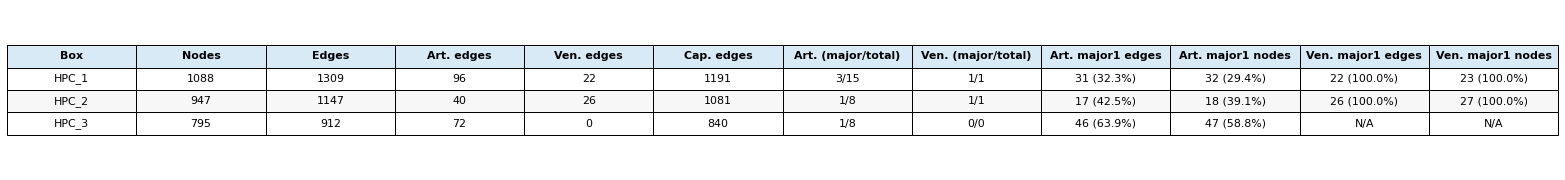

Saved table image: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_major_trees_table.png


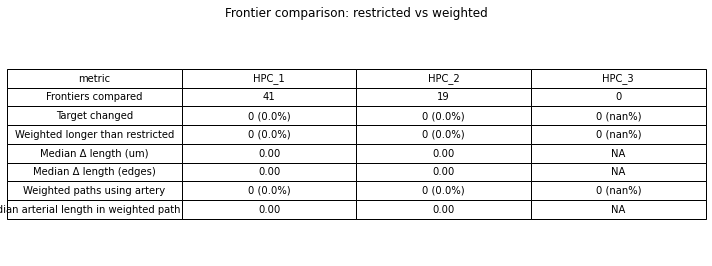

Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_summary.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_redundancy.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_mincut.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_saturation.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_av_path_stats.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_av_path_sizes.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_hdn_nodes.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_trimmed_paths.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_density_subboxes.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_frontier_comparison_detail.csv
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_frontier_comparison_summ

In [19]:
# --- build global dataframes ---
summary_df        = pd.DataFrame(all_summaries)
df_redundancy     = pd.DataFrame(redundancy_rows)
df_mincut         = pd.DataFrame(mincut_rows)
df_saturation     = pd.DataFrame(saturation_rows)
df_av             = pd.DataFrame(av_rows)
df_av_path_sizes  = pd.DataFrame(av_path_size_rows)
df_hdn_nodes      = pd.DataFrame(hdn_nodes_rows)
df_trimmed_global = pd.DataFrame(trimmed_rows)
df_density_all    = pd.DataFrame(density_boxes_rows)

df_comparison     = pd.concat(comparison_detail_rows, ignore_index=True) if comparison_detail_rows else pd.DataFrame()
df_cmp_summary    = pd.DataFrame(comparison_summ_rows)
df_bc_global      = pd.concat(bc_rows,      ignore_index=True) if bc_rows      else pd.DataFrame()
df_bc_long        = pd.concat(bc_long_rows, ignore_index=True) if bc_long_rows else pd.DataFrame()
df_diam_length    = pd.concat(diam_length_rows, ignore_index=True) if diam_length_rows else pd.DataFrame()

# --- major trees table ---
table_png = os.path.join(out_root, f"{REGION}_major_trees_table.png")
save_major_trees_table_png(summary_df, table_png, graph_order=BOX_ORDER)

# --- frontier comparison summary table ---
if not df_cmp_summary.empty:
    df_cmp_table = build_frontier_comparison_summary_table_restricted_vs_weighted(
        df_cmp_summary, graphs_order=BOX_ORDER)
    fig, ax = dataframe_to_table_figure(
        df_cmp_table, title="Frontier comparison: restricted vs weighted",
        figsize=(10, 3.8), round_decimals=3)
    fig.savefig(os.path.join(out_root, f"{REGION}_frontier_comparison_table.png"),
                dpi=200, bbox_inches="tight")
    plt.close(fig)

# --- save all CSVs ---
def _save(df, fname):
    if not df.empty:
        p = os.path.join(out_root, fname)
        df.to_csv(p, index=False)
        print("Saved:", p)

_save(summary_df,        f"{REGION}_summary.csv")
_save(df_redundancy,     f"{REGION}_redundancy.csv")
_save(df_mincut,         f"{REGION}_mincut.csv")
_save(df_saturation,     f"{REGION}_saturation.csv")
_save(df_av,             f"{REGION}_av_path_stats.csv")
_save(df_av_path_sizes,  f"{REGION}_av_path_sizes.csv")
_save(df_hdn_nodes,      f"{REGION}_hdn_nodes.csv")
_save(df_trimmed_global, f"{REGION}_trimmed_paths.csv")
_save(df_density_all,    f"{REGION}_density_subboxes.csv")
_save(df_comparison,     f"{REGION}_frontier_comparison_detail.csv")
_save(df_cmp_summary,    f"{REGION}_frontier_comparison_summary.csv")
_save(df_bc_global,      f"{REGION}_bc_faces.csv")
_save(df_bc_long,        f"{REGION}_bc_diameter_long.csv")
_save(df_diam_length,    f"{REGION}_diameter_length.csv")

print("\nAll global CSVs saved.")

---
## 5. Plots

Each sub-section is independent — re-run any single cell without re-running the loop.

### 5.0 Edges types & Nodes

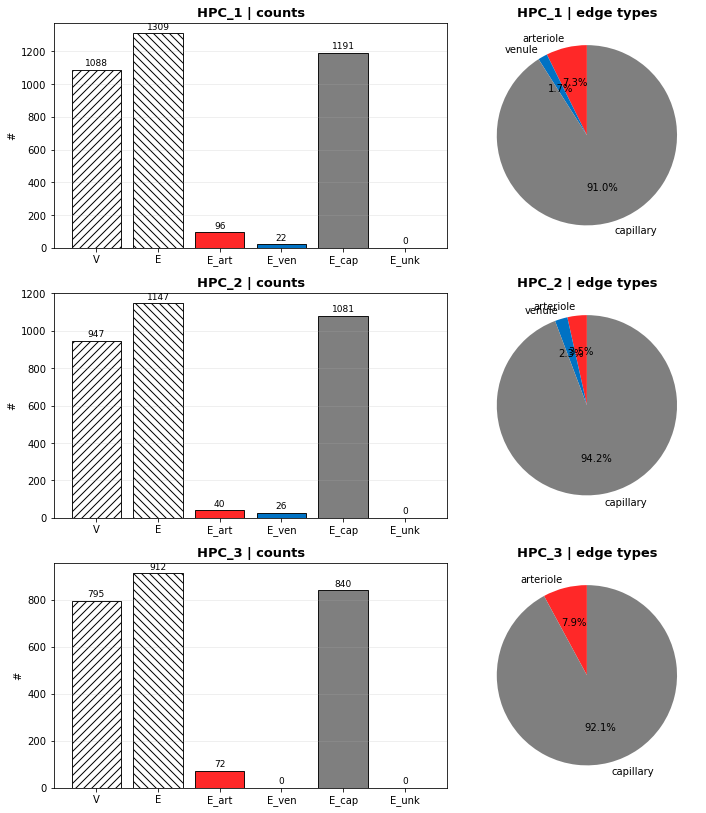

In [20]:
if not summary_df.empty:
    plot_pies_with_bars_edge_types(summary_df, box_order=BOX_ORDER, type_colors=VESSEL_COLORS)

### 5.1 Connectivity & Redundancy

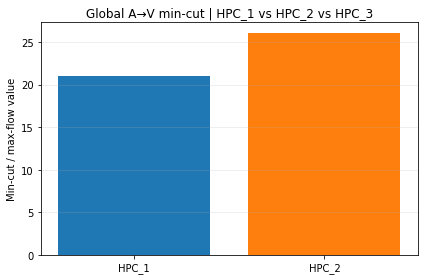

graph  min_cut_value  max_flow_value  n_cut_edges  n_arterial_nodes  n_venous_nodes  min_cut_n_arteriole_edges  min_cut_n_venule_edges  min_cut_n_capillary_edges  min_cut_n_unknown_edges
HPC_1           21.0            21.0           21               109              23                          0                       0                         21                        0
HPC_2           26.0            26.0           26                46              27                          0                       0                         26                        0
HPC_3            NaN             NaN            0                 0               0                          0                       0                          0                        0


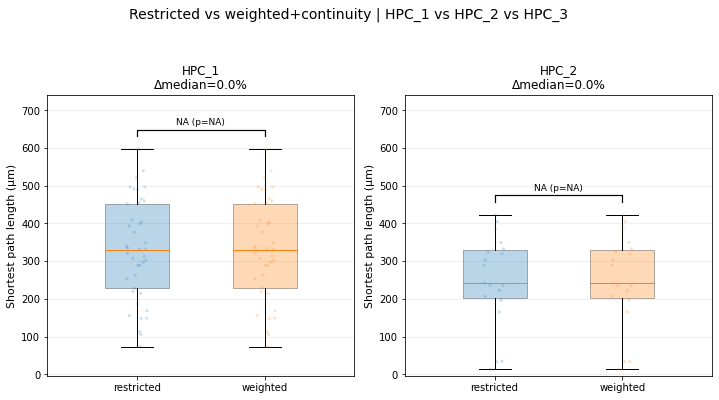

Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_frontier_comparison_boxplot_stats.csv


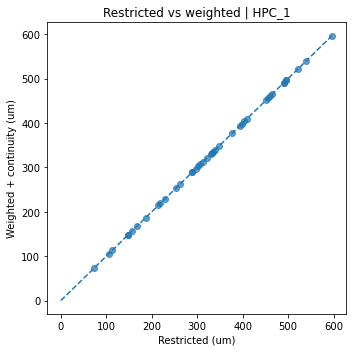

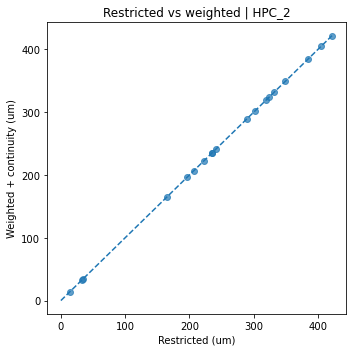

No paired data for HPC_3


In [21]:
# take into consideration that as we are only using capacity = 1 for all edges, min cut = number of independent paths. 

if not df_mincut.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(df_mincut["graph"], df_mincut["min_cut_value"], color=[BOX_COL[g] for g in df_mincut["graph"]])
    plt.ylabel("Min-cut / max-flow value")
    plt.title(f"Global A→V min-cut | {BOX_LABEL}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(out_root, f"{REGION}_mincut_barplot.png"), dpi=150)
    plt.show()
    print(df_mincut.to_string(index=False))


# Frontier comparison paired boxplots
if not df_comparison.empty:
    stats_paired = plot_paired_restricted_vs_weighted_boxplots_from_comparison(
        df_comparison, graphs_order=BOX_ORDER,
        ylabel="Shortest path length (µm)",
        title=f"Restricted vs weighted+continuity | {BOX_LABEL}")
    _save(stats_paired, f"{REGION}_frontier_comparison_boxplot_stats.csv")

    for g in BOX_ORDER:
        plot_restricted_vs_weighted_scatter(df_comparison, g)
       

### 5.2 Saturation

graph  n_ac_cap_edges_total  n_vc_cap_edges_total  ac_frontier_nodes_total  ac_frontier_nodes_used  vc_nodes_total  vc_nodes_reached  capillary_edges_attached_to_artery  capillary_edges_attached_to_vein  n_independent_paths  saturation_ac_edges  saturation_vc_edges
HPC_1                    70                  24.0                       44                      41              23                 9                                  71                              25.0                   21             0.300000             0.875000
HPC_2                    37                  38.0                       22                      19              27                 9                                  37                              38.0                   26             0.702703             0.684211
HPC_3                    52                   NaN                       32                       0               0                 0                                  55                               NaN

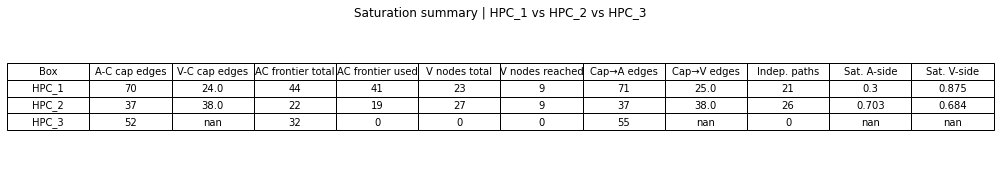

In [22]:
if not df_saturation.empty:
    cols_to_show = [
        "graph",
        "n_ac_cap_edges_total",
        "n_vc_cap_edges_total",
        "ac_frontier_nodes_total",
        "ac_frontier_nodes_used",
        "vc_nodes_total",
        "vc_nodes_reached",
        "capillary_edges_attached_to_artery",
        "capillary_edges_attached_to_vein",
        "n_independent_paths",
        "saturation_ac_edges",
        "saturation_vc_edges",
    ]
    cols_to_show = [c for c in cols_to_show if c in df_saturation.columns]
    print(df_saturation[cols_to_show].to_string(index=False))

    '''
    Right now, not intereseted in these plots, not so informative


    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, col, title in zip(
        axes,
        ["saturation_ac_edges", "saturation_vc_edges"],
        ["A-side saturation (cap edges)", "V-side saturation (cap edges)"]):

        vals = df_saturation[col].to_numpy(float)
        colors = [BOX_COL[g] for g in df_saturation["graph"]]
        ax.bar(df_saturation["graph"], vals, color=colors)
        ax.set_ylabel("Saturation (fraction)")
        ax.set_title(title)
        ax.set_ylim(0, 1.05)
        ax.axhline(1.0, linestyle="--", color="gray", linewidth=0.8)
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(f"Interface saturation | {BOX_LABEL}")
    plt.tight_layout()
    plt.savefig(os.path.join(out_root, f"{REGION}_saturation_barplot.png"), dpi=150)
    plt.show()
    
    # raw counts
    for col in ["n_ac_cap_edges_total", "n_vc_cap_edges_total",
                "ac_frontier_nodes_total", "ac_frontier_nodes_used",
                "vc_nodes_total", "vc_nodes_reached",
                "capillary_edges_attached_to_artery", "capillary_edges_attached_to_vein"]:
        if col not in df_saturation.columns:
            continue
        plt.figure(figsize=(6, 4))
        plt.bar(df_saturation["graph"], df_saturation[col],
                color=[BOX_COL[g] for g in df_saturation["graph"]])
        plt.ylabel(col)
        plt.title(f"{col} | {BOX_LABEL}")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()
    '''
    
# renombrar para que quede más legible en la figura
    rename_map = {
        "graph":                              "Box",
        "n_ac_cap_edges_total":               "A-C cap edges",
        "n_vc_cap_edges_total":               "V-C cap edges",
        "ac_frontier_nodes_total":            "AC frontier total",
        "ac_frontier_nodes_used":             "AC frontier used",
        "vc_nodes_total":                     "V nodes total",
        "vc_nodes_reached":                   "V nodes reached",
        "capillary_edges_attached_to_artery": "Cap→A edges",
        "capillary_edges_attached_to_vein":   "Cap→V edges",
        "n_independent_paths":                "Indep. paths",
        "saturation_ac_edges":                "Sat. A-side",
        "saturation_vc_edges":                "Sat. V-side",
    }
    sat_table = df_saturation[cols_to_show].rename(columns=rename_map)
    fig, ax = dataframe_to_table_figure(
        sat_table,
        title=f"Saturation summary | {BOX_LABEL}",
        figsize=(14, 2.5),
        round_decimals=3,
    )
    fig.savefig(os.path.join(out_root, f"{REGION}_saturation_table.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

### 5.3 Shortest Paths

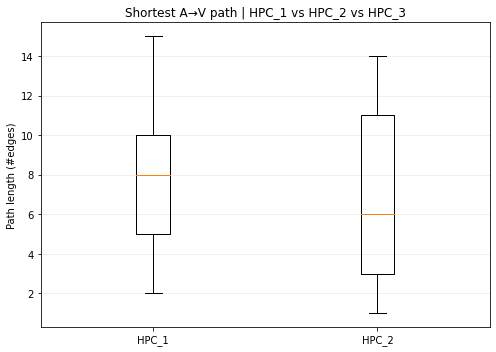

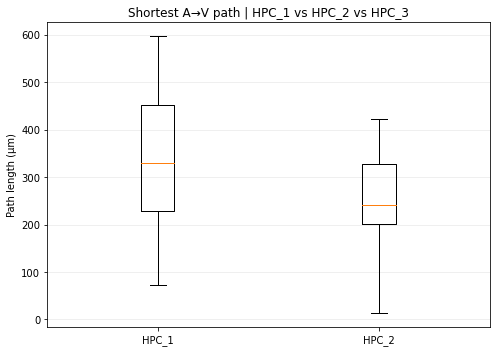

'\n1st approach: accepting continuity through artery, check to see shortest only capillary path and how much is trimmed\n\nif not df_trimmed_global.empty:\n    for col, label in [\n        ("full_len_um",              "Full path length (µm)"),\n        ("trimmed_capillary_len_um", "Trimmed capillary length (µm)"),\n        ("removed_um",              "Removed length (µm)"),\n        ("removed_frac",            "Removed fraction"),\n    ]:\n        plot_boxplot_by_graph(df_trimmed_global, col,\n                              title=f"{label} | {BOX_LABEL}",\n                              ylabel=label, graphs_order=BOX_ORDER)\n\n    # scatter: full vs trimmed\n    plt.figure(figsize=(5, 5))\n    x = df_trimmed_global["full_len_um"].to_numpy(float)\n    y = df_trimmed_global["trimmed_capillary_len_um"].to_numpy(float)\n    m = np.isfinite(x) & np.isfinite(y)\n    plt.scatter(x[m], y[m], alpha=0.5, s=10)\n    mx = max(np.max(x[m]), np.max(y[m]))\n    plt.plot([0, mx], [0, mx], "--", color="g

In [23]:
if not df_av_path_sizes.empty:
    for col, label in [("path_len_edges", "Path length (#edges)"),
                       ("path_len_um",    "Path length (µm)")]:
        plot_boxplot_by_graph(df_av_path_sizes, col,
                              title=f"Shortest A→V path | {BOX_LABEL}",
                              ylabel=label, graphs_order=BOX_ORDER)
'''
1st approach: accepting continuity through artery, check to see shortest only capillary path and how much is trimmed

if not df_trimmed_global.empty:
    for col, label in [
        ("full_len_um",              "Full path length (µm)"),
        ("trimmed_capillary_len_um", "Trimmed capillary length (µm)"),
        ("removed_um",              "Removed length (µm)"),
        ("removed_frac",            "Removed fraction"),
    ]:
        plot_boxplot_by_graph(df_trimmed_global, col,
                              title=f"{label} | {BOX_LABEL}",
                              ylabel=label, graphs_order=BOX_ORDER)

    # scatter: full vs trimmed
    plt.figure(figsize=(5, 5))
    x = df_trimmed_global["full_len_um"].to_numpy(float)
    y = df_trimmed_global["trimmed_capillary_len_um"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)
    plt.scatter(x[m], y[m], alpha=0.5, s=10)
    mx = max(np.max(x[m]), np.max(y[m]))
    plt.plot([0, mx], [0, mx], "--", color="gray")
    plt.xlabel("Full path (µm)")
    plt.ylabel("Trimmed capillary path (µm)")
    plt.title(f"Full vs trimmed | {BOX_LABEL}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(out_root, f"{REGION}_full_vs_trimmed_scatter.png"), dpi=150)
    plt.show()
'''

### 5.4 Vessel Density

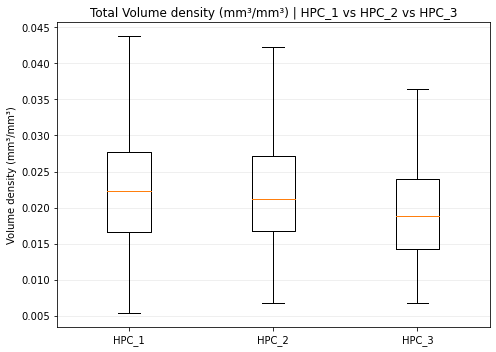

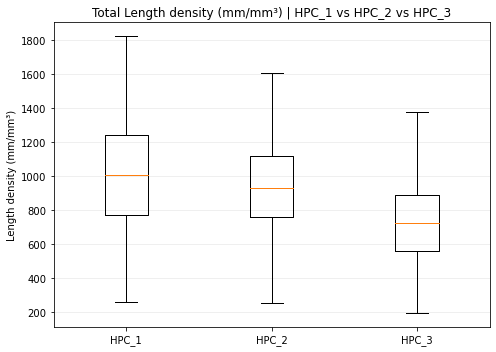

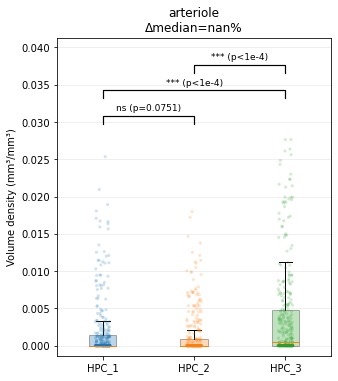

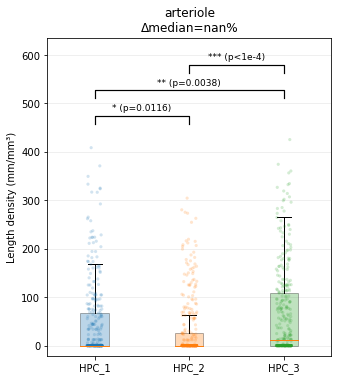

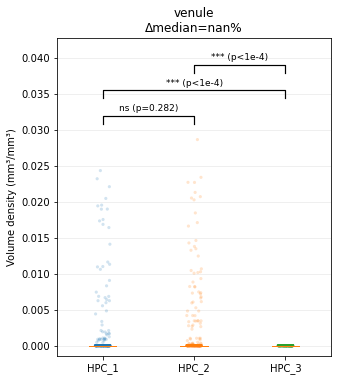

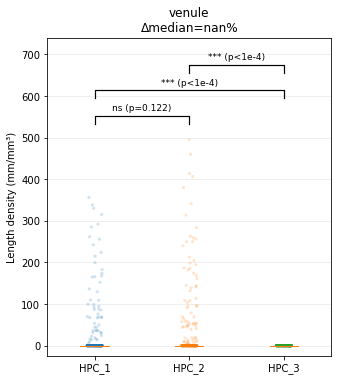

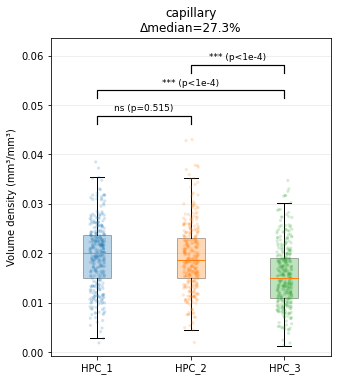

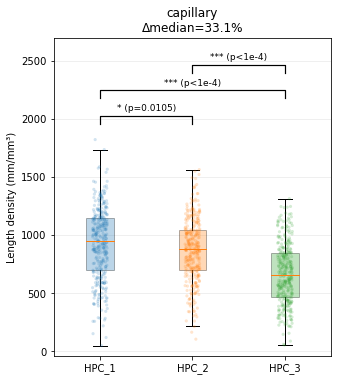

Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_density_pairwise_ttests.csv


In [24]:
if not df_density_all.empty:
    df_density_total = df_density_all[df_density_all["type"] == "total"]

    for col, label in [("vessel_volume_density", "Volume density (mm³/mm³)"),
                       ("vessel_length_density", "Length density (mm/mm³)")]:
        plot_boxplot_by_graph(df_density_total, col,
                              title=f"Total {label} | {BOX_LABEL}",
                              ylabel=label, graphs_order=BOX_ORDER)

    for t in ["arteriole", "venule", "capillary"]:
        sub = df_density_all[df_density_all["type"] == t]
        if sub.empty:
            continue
        for col, label in [("vessel_volume_density", "Volume density (mm³/mm³)"),
                           ("vessel_length_density", "Length density (mm/mm³)")]:
            plot_simple_type_boxplots_with_stats(
                sub, value_col=col, ylabel=label,
                graphs_order=BOX_ORDER, types_order=("arteriole", "venule", "capillary"),
                box_colors=BOX_COL)

    # pairwise t-tests
    dens_stats = []
    for col in ["vessel_volume_density", "vessel_length_density"]:
        for t in ["arteriole", "venule", "capillary"]:
            sub = df_density_all[df_density_all["type"] == t]
            if sub.empty:
                continue
            st = pairwise_ttests_table(sub, col, BOX_ORDER)
            if not st.empty:
                st["type"] = t
                dens_stats.append(st)
    if dens_stats:
        df_dens_stats = pd.concat(dens_stats, ignore_index=True)
        _save(df_dens_stats, f"{REGION}_density_pairwise_ttests.csv")

### 5.5 Diameter & Length 

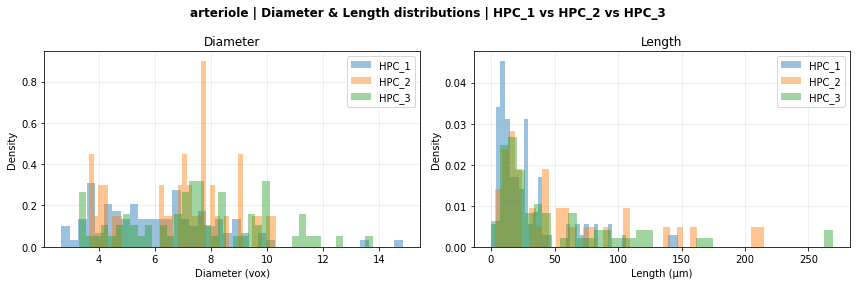

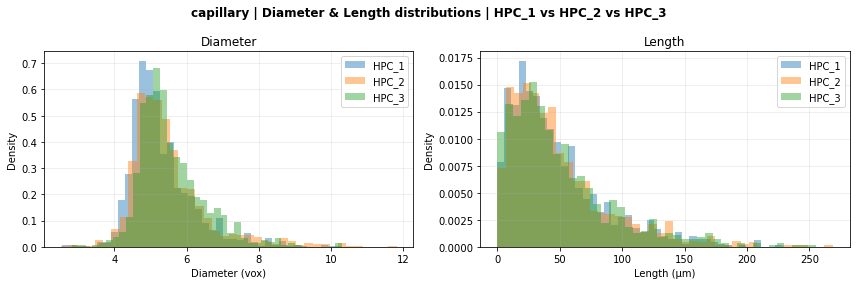

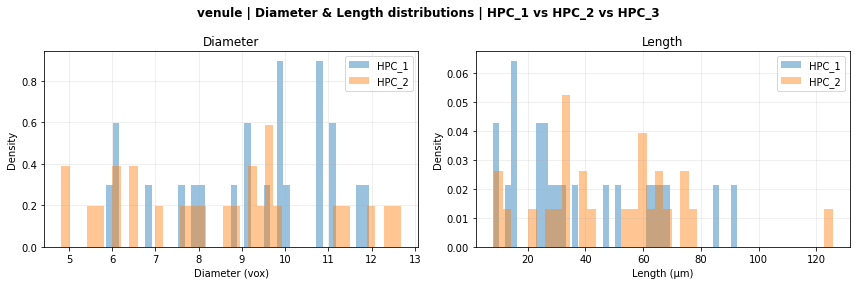

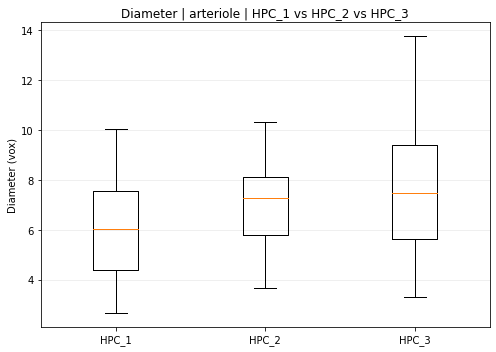

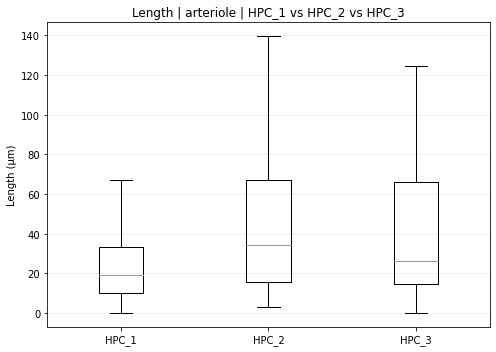

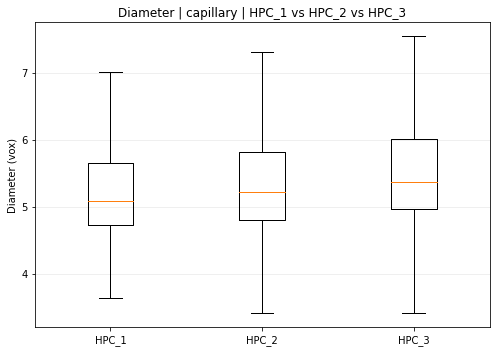

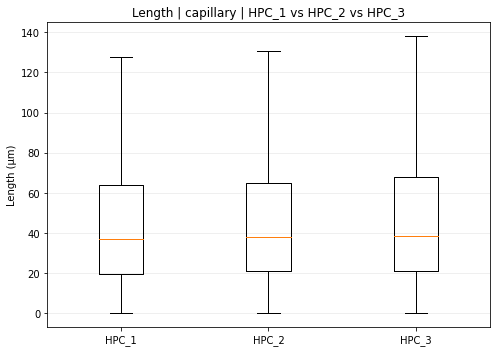

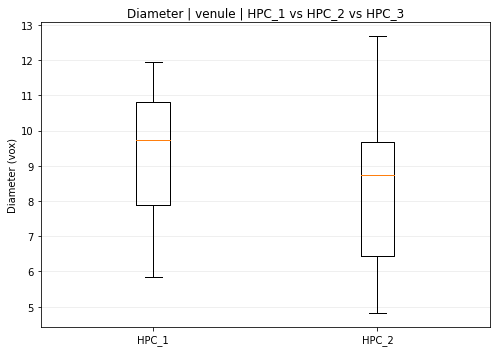

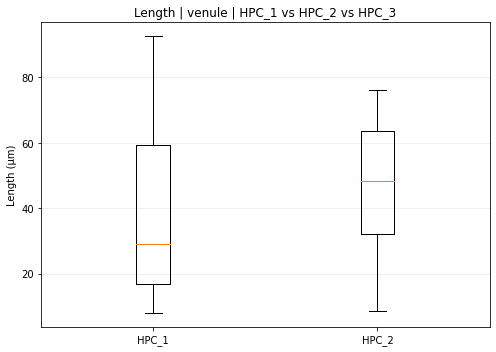

In [25]:
if not df_diam_length.empty:
    dl = df_diam_length.copy()
    dl["type"] = dl["type"].astype(str)

    diameter_length_overlay_by_type(dl, bins=bins_hist, box_label=BOX_LABEL)

    for t in sorted(dl["type"].unique()):
        sub = dl[dl["type"] == t]
        plot_boxplot_by_graph(sub, "diameter_vox",
                              title=f"Diameter | {t} | {BOX_LABEL}",
                              ylabel="Diameter (vox)", graphs_order=BOX_ORDER)
        plot_boxplot_by_graph(sub, "length_um",
                              title=f"Length | {t} | {BOX_LABEL}",
                              ylabel="Length (µm)", graphs_order=BOX_ORDER)

### 5.6 Boundary Conditions

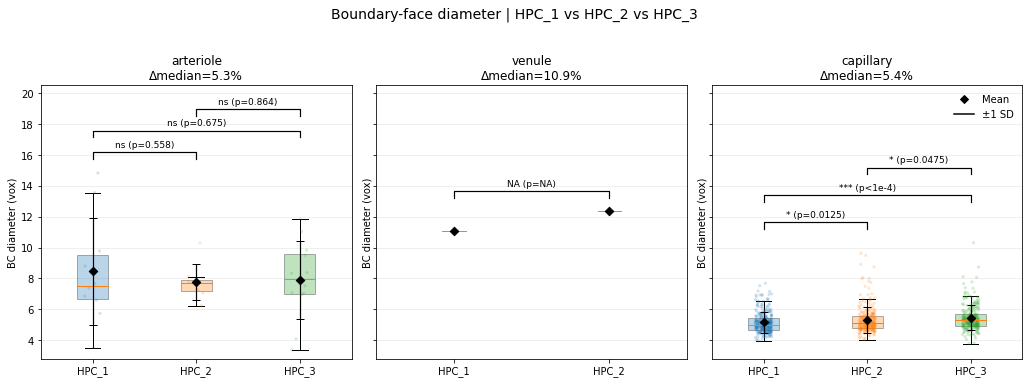

Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_bc_diameter_stats.csv

BC pooled summary:
graph      type   n      mean    median      std  total       pct
HPC_1 arteriole  10  8.476760  7.528005 3.464421    313  3.194888
HPC_1 capillary 302  5.153538  5.017806 0.663756    313 96.485623
HPC_1    venule   1 11.065616 11.065616      NaN    313  0.319489
HPC_2 arteriole   8  7.770684  7.686869 1.175168    283  2.826855
HPC_2 capillary 274  5.312400  5.098489 0.837769    283 96.819788
HPC_2    venule   1 12.340442 12.340442      NaN    283  0.353357
HPC_3 arteriole  12  7.916058  7.937364 2.513976    276  4.347826
HPC_3 capillary 264  5.453696  5.294491 0.812028    276 95.652174
Saved: /home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED/HPC_bc_pooled.csv


In [26]:
if not df_bc_long.empty:
    bc_plot = df_bc_long.rename(columns={"vessel_type": "type"}).copy()
    bc_plot  = bc_plot[bc_plot["type"].isin(["arteriole", "venule", "capillary"])]

    bc_stats = plot_simple_type_boxplots_with_stats(
        dl=bc_plot, value_col="diameter", ylabel="BC diameter (vox)",
        graphs_order=BOX_ORDER, types_order=("arteriole", "venule", "capillary"),
        box_colors=BOX_COL,
        title=f"Boundary-face diameter | {BOX_LABEL}",
        show_mean_std=True)

    _save(bc_stats, f"{REGION}_bc_diameter_stats.csv")

    # pooled summary table
    bc_pooled = (
        bc_plot.groupby(["graph", "type"])["diameter"]
        .agg(n="size", mean="mean", median="median", std="std")
        .reset_index()
    )
    totals = bc_plot.groupby("graph").size().rename("total").reset_index()
    bc_pooled = bc_pooled.merge(totals, on="graph", how="left")
    bc_pooled["pct"] = 100 * bc_pooled["n"] / bc_pooled["total"]
    print("\nBC pooled summary:")
    print(bc_pooled.sort_values(["graph", "type"]).to_string(index=False))
    _save(bc_pooled, f"{REGION}_bc_pooled.csv")

---
*End of notebook*